# Breast Cancer Biomarker Discovery via LASSO Regression

**Dataset:** GSE42568: 104 breast cancer + 17 normal breast tissue transcriptomic profiles (Affymetrix U133 Plus 2.0).

**Objective:** Parse the GEO SOFT series matrix, verify sample alignment, standardise the expression matrix, and apply L1-regularised regression (LassoCV) to identify the most predictive gene probes for distinguishing cancer from normal tissue.

In [ ]:
#impors, np , pd and plt are all standard as ofr sklearn funcs their usage will be discussed in their respectve part of the code.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import accuracy_score, classification_report

# path to the dataset file
DATA_PATH = "data/GSE42568_series_matrix.txt"

## Data Parsing & Alignment Verification

We scan the metadata header line-by-line to extract three things:
- **Target labels (y):** from the `!Sample_characteristics_ch1` row containing `"tissue:"`
- **Sample IDs:** from the `!Sample_geo_accession` row
- **Matrix start line:** where the actual expression data begins

In [ ]:
# parse metadata in a single pass through the file
y = None               # will hold our binary labels (0 = normal, 1 = cancer)
sample_ids = None      # will hold the GSM sample ID strings (used for verification only)
matrix_start_line = None  # line number where the expression table begins

#we will use those 3 to inform how our pd_read_csv will get the actual DataFrame
with open(DATA_PATH, "r") as f:
    for line_num, line in enumerate(f, start=1):

        #reading the dataset, the labels used for cancerous tissue was under !sample_characteristics_ch1 formatted in a tissue: normal and breast cancer
        #this wont apply to other datasets of course
        #look for the "tissue:" characteristics row to build our labels
        if line.startswith("!Sample_characteristics_ch1") and "tissue:" in line:
            fields = line.strip().split("\t")[1:]   # skip the row name, keep sample values
            y = np.array(
                #if value after tissue is "normal breast" if its not that then it is breast cancer
                [0 if "normal breast" in v else 1 for v in fields],
                dtype=int,
            )

        #locate for sample_geo_accession ids to verify
        if line.startswith("!Sample_geo_accession"):
            sample_ids = [
                v.strip().strip('"') for v in line.strip().split("\t")[1:]
            ]

        #look for the marker that tells us where the data table starts
        if line.startswith("!series_matrix_table_begin"):
            matrix_start_line = line_num
            break  # no need to read further

# verify everything  that was found
if y is None:
    print("ERROR: Could not find the 'tissue:' row in metadata.")
elif sample_ids is None:
    print("ERROR: Could not find the Sample_geo_accession row.")
elif len(y) != len(sample_ids):
    print(f"ERROR: Length mismatch {len(y)} labels vs {len(sample_ids)} sample IDs.")
else:
    n_normal = int((y == 0).sum())
    n_cancer = int((y == 1).sum())
    print(f"Verification passed: {len(y)} labels and {len(sample_ids)} sample IDs")
    print(f"  Normal breast: {n_normal}")
    print(f"  Breast cancer: {n_cancer}")
    print(f"  Matrix data starts after line {matrix_start_line}")

Verification passed: 121 labels and 121 sample IDs
  Normal breast: 17
  Breast cancer: 104
  Matrix data starts after line 78


## 2 — Load & Preprocess the Expression Matrix

GEO series matrix files store the data in **gene-major** format:
- Rows = gene probes (~54,000)
- Columns = patient samples (~121)

But scikit-learn expects **sample-major** format (rows = observations, columns = features),
so we **transpose** the matrix after loading.

Steps:
1. Read the tab-delimited table below the `!series_matrix_table_begin` marker.
2. Drop the trailing `!series_matrix_table_end` row at the bottom.
3. Transpose so rows = samples, columns = gene probes.
4. Standardise with `StandardScaler` so every feature has mean 0 and std 1.

In [3]:
# --- Load the expression data table ---
expr = pd.read_csv(
    DATA_PATH,
    sep="\t",
    skiprows=matrix_start_line,   # skip all header lines
    index_col=0,                  # use ID_REF column as the row index
)

# Remove the "!series_matrix_table_end" sentinel at the bottom
if expr.index[-1].startswith("!"):
    expr = expr.iloc[:-1]

# Show what the raw data looks like BEFORE transposing
print("BEFORE transpose (gene-major):")
print(f"  Shape: {expr.shape}  (genes x samples)")
print(f"  Rows are gene probes, columns are patient samples")
print()
print(expr.iloc[:5, :5])  # first 5 genes, first 5 samples
print()

BEFORE transpose (gene-major):
  Shape: (54675, 121)  (genes x samples)
  Rows are gene probes, columns are patient samples

           GSM1045191  GSM1045192  GSM1045193  GSM1045194  GSM1045195
ID_REF                                                               
1007_s_at    5.640239    3.557696    3.132007    6.865108    4.955184
1053_at      5.074866    4.984593    5.109481    5.473609    5.348400
117_at       4.191770    4.269061    4.131843    3.616546    4.296657
121_at       3.574706    4.065623    3.574706    3.574706    3.799293
1255_g_at    2.312812    2.409371    2.312812    2.312812    2.349630



In [4]:
# --- Transpose so that rows = patient samples, columns = gene probes ---
X_df = expr.T

# Make sure everything is numeric (convert stray strings to NaN, then fill with 0)
X_df = X_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Show what it looks like AFTER transposing
print("AFTER transpose (sample-major — what sklearn expects):")
print(f"  Shape: {X_df.shape}  (samples x probes)")
print(f"  Rows are patient samples, columns are gene probes")
print()
print(X_df.iloc[:5, :5])  # first 5 samples, first 5 genes

AFTER transpose (sample-major — what sklearn expects):
  Shape: (121, 54675)  (samples x probes)
  Rows are patient samples, columns are gene probes

ID_REF      1007_s_at   1053_at    117_at    121_at  1255_g_at
GSM1045191   5.640239  5.074866  4.191770  3.574706   2.312812
GSM1045192   3.557696  4.984593  4.269061  4.065623   2.409371
GSM1045193   3.132007  5.109481  4.131843  3.574706   2.312812
GSM1045194   6.865108  5.473609  3.616546  3.574706   2.312812
GSM1045195   4.955184  5.348400  4.296657  3.799293   2.349630


In [5]:
# --- Standardise the features ---
# This ensures the LASSO penalty treats all genes equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

print(f"Standardised matrix shape: {X_scaled.shape}")
print(f"Mean ~ 0 check (first 5 cols): {X_scaled.mean(axis=0)[:5].round(6)}")
print(f"Std  ~ 1 check (first 5 cols): {X_scaled.std(axis=0)[:5].round(6)}")

Standardised matrix shape: (121, 54675)
Mean ~ 0 check (first 5 cols): [-0.  0.  0. -0.  0.]
Std  ~ 1 check (first 5 cols): [1. 1. 1. 1. 1.]


## 2b — PCA Diagnostic & Visualisation

Before building any model, we use PCA to check:
- Do cancer and normal samples separate naturally (without using labels)?
- Are there outliers or batch effects?
- How many components capture most of the variance?

In [6]:
# --- Fit PCA ---
pca_full = PCA(n_components=min(20, X_scaled.shape[0]))
X_pca = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"PC1 explains {explained[0]*100:.1f}% of variance")
print(f"PC2 explains {explained[1]*100:.1f}% of variance")
print(f"PC1+PC2 cumulative: {cumulative[1]*100:.1f}%")
print(f"Components needed for 80% variance: {np.searchsorted(cumulative, 0.80) + 1}")

PC1 explains 11.9% of variance
PC2 explains 7.1% of variance
PC1+PC2 cumulative: 19.0%
Components needed for 80% variance: 21


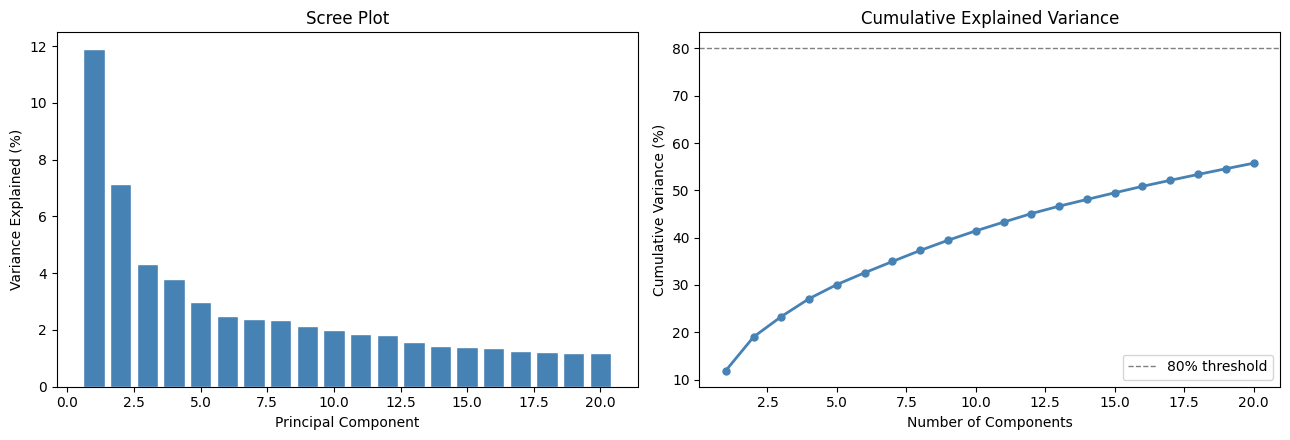

In [7]:
# --- Scree plot (how much variance each component explains) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: individual variance per component
axes[0].bar(range(1, len(explained)+1), explained * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')

# Right panel: cumulative variance
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100,
             'o-', color='steelblue', lw=2, markersize=5)
axes[1].axhline(80, ls='--', color='grey', lw=1, label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

fig.tight_layout()
plt.show()

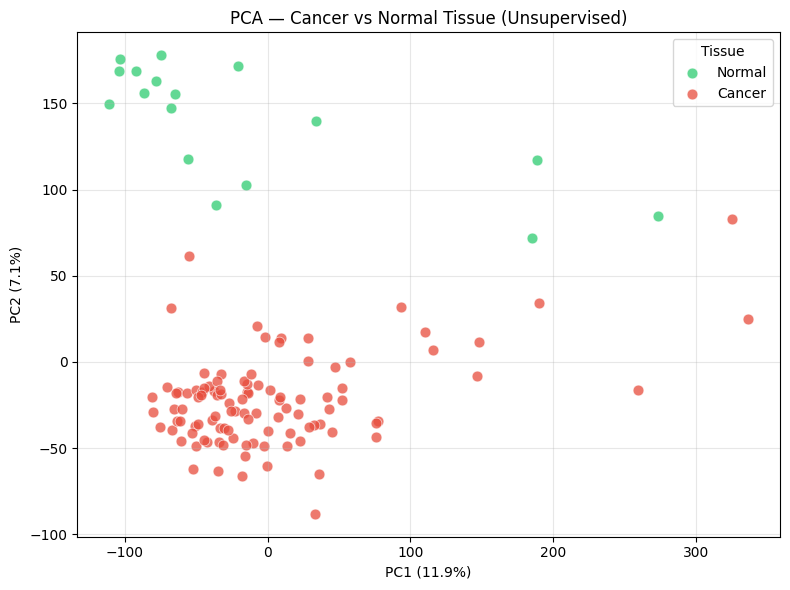


If the two groups separate cleanly, the biological signal is real
and not caused by batch effects or labelling errors.


In [8]:
# --- 2D scatter plot: PC1 vs PC2, coloured by tissue type ---
labels_str = np.where(y == 0, 'Normal', 'Cancer')
colors = {'Normal': '#2ecc71', 'Cancer': '#e74c3c'}

fig, ax = plt.subplots(figsize=(8, 6))
for label in ['Normal', 'Cancer']:
    mask = labels_str == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[label], label=label, s=60,
               alpha=0.75, edgecolors='white', lw=0.5)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA — Cancer vs Normal Tissue (Unsupervised)')
ax.legend(title='Tissue', frameon=True)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print()
print('If the two groups separate cleanly, the biological signal is real')
print('and not caused by batch effects or labelling errors.')

## 3 — LASSO Regression (LassoCV)

LASSO = Least Absolute Shrinkage and Selection Operator.  
It adds an L1 penalty to linear regression, which forces most gene coefficients to **exactly zero**.  
The genes that survive (non-zero coefficients) are the selected biomarkers.

`LassoCV` automatically tries many penalty strengths (alpha values) using 5-fold cross-validation and picks the best one.

In [9]:
# --- Fit LassoCV (auto-selects best alpha) ---
lasso = LassoCV(cv=5, random_state=42, max_iter=10_000)
lasso.fit(X_scaled, y)

print(f"Optimal alpha found: {lasso.alpha_:.6f}")
print(f"Non-zero features:   {(lasso.coef_ != 0).sum()} out of {len(lasso.coef_)}")

Optimal alpha found: 0.002180
Non-zero features:   91 out of 54675


## 3b — Refined LASSO: Targeting 20–25 Biomarkers

The initial LassoCV selected ~91 features — still a lot. PCA showed that about **21 components**
capture 80% of the variance, suggesting the data really only has ~20 independent dimensions.

So we now search for a **stricter alpha** that narrows the model down to exactly **20–25 genes**.
We use binary search: start from the CV-optimal alpha and increase it until only 20–25 genes remain.

In [10]:
# --- Binary search for the right alpha ---
TARGET_MIN = 20    # we want at least this many genes
TARGET_MAX = 25    # but no more than this

alpha_lo = lasso.alpha_    # starting point (too many features)
alpha_hi = 0.5             # very strong penalty (almost no features)

best_alpha = None
best_n_features = None

for i in range(100):  # binary search iterations
    alpha_mid = (alpha_lo + alpha_hi) / 2

    # Fit a Lasso with this alpha and count non-zero genes
    model = Lasso(alpha=alpha_mid, max_iter=10_000)
    model.fit(X_scaled, y)
    n_feat = (model.coef_ != 0).sum()

    # Check if we're in the target range
    if TARGET_MIN <= n_feat <= TARGET_MAX:
        best_alpha = alpha_mid
        best_n_features = n_feat
        print(f"Found target in {i+1} iterations")
        break
    elif n_feat > TARGET_MAX:
        alpha_lo = alpha_mid   # too many genes -> increase penalty
    else:
        alpha_hi = alpha_mid   # too few genes -> decrease penalty

# If binary search couldn't land exactly in [20, 25], use the closest result
if best_alpha is None:
    best_alpha = alpha_mid
    best_n_features = n_feat
    print(f"Warning: closest result was {n_feat} features (target was {TARGET_MIN}-{TARGET_MAX})")

# --- Fit the final strict model ---
lasso_strict = Lasso(alpha=best_alpha, max_iter=10_000)
lasso_strict.fit(X_scaled, y)

print(f"")
print(f"CV-optimal alpha:  {lasso.alpha_:.6f}  ->  {(lasso.coef_ != 0).sum()} genes")
print(f"Strict alpha:      {best_alpha:.6f}  ->  {best_n_features} genes")
print(f"Alpha multiplier:  {best_alpha / lasso.alpha_:.1f}x")

Found target in 6 iterations

CV-optimal alpha:  0.002180  ->  91 genes
Strict alpha:      0.056629  ->  24 genes
Alpha multiplier:  26.0x


In [11]:
# --- Show the refined biomarker panel ---
coef_strict = pd.Series(lasso_strict.coef_, index=X_df.columns, name="coefficient")
nonzero_strict = coef_strict[coef_strict != 0].copy()
nonzero_strict = nonzero_strict.reindex(nonzero_strict.abs().sort_values(ascending=False).index)

panel = nonzero_strict.to_frame()
panel.index.name = "Probe_ID"
panel["abs_coefficient"] = panel["coefficient"].abs()
panel["direction"] = np.where(panel["coefficient"] > 0, "up in cancer", "down in cancer")
panel["rank"] = range(1, len(panel) + 1)

# Quick accuracy check on the strict model
y_pred_strict = (lasso_strict.predict(X_scaled) > 0.5).astype(int)
acc_strict = accuracy_score(y, y_pred_strict)

print(f"Strict LASSO selected {len(panel)} biomarker probes")
print(f"Training accuracy:  {acc_strict:.4f}")
print(f"R2 (in-sample):     {lasso_strict.score(X_scaled, y):.4f}")
print()
print("=" * 65)
print(f"  REFINED BIOMARKER PANEL ({len(panel)} probes, alpha = {best_alpha:.6f})")
print("=" * 65)
panel

Strict LASSO selected 24 biomarker probes
Training accuracy:  1.0000
R2 (in-sample):     0.9231

  REFINED BIOMARKER PANEL (24 probes, alpha = 0.056629)


,coefficient,abs_coefficient,direction,rank
Probe_ID,,,,
235201_at,-0.063947,0.063947,down in cancer,1
236461_at,-0.045917,0.045917,down in cancer,2
230595_at,-0.042055,0.042055,down in cancer,3
207276_at,-0.025659,0.025659,down in cancer,4
236927_at,-0.023217,0.023217,down in cancer,5
235670_at,-0.022950,0.022950,down in cancer,6
239811_at,0.016637,0.016637,up in cancer,7
232313_at,-0.016105,0.016105,down in cancer,8
219059_s_at,-0.015469,0.015469,down in cancer,9


## 4 — Results: Top Biomarker Probes (Initial LassoCV)

For reference, here are the top 20 probes from the original (less strict) LassoCV model.

In [12]:
# --- Extract and rank non-zero coefficients ---
coef_series = pd.Series(lasso.coef_, index=X_df.columns, name="coefficient")
nonzero = coef_series[coef_series != 0].copy()
nonzero = nonzero.reindex(nonzero.abs().sort_values(ascending=False).index)

print(f"Total probes:           {len(coef_series):,}")
print(f"Non-zero (selected):    {len(nonzero):,}")
print(f"Zeroed-out (excluded):  {(coef_series == 0).sum():,}")
print()

# --- Show the top 20 ---
top20 = nonzero.head(20).to_frame()
top20.index.name = "Probe_ID"
top20["abs_coefficient"] = top20["coefficient"].abs()
top20["direction"] = np.where(top20["coefficient"] > 0, "up in cancer", "down in cancer")

print("=" * 60)
print("  TOP 20 LASSO-SELECTED BREAST CANCER BIOMARKER PROBES")
print("=" * 60)
top20

Total probes:           54,675
Non-zero (selected):    91
Zeroed-out (excluded):  54,584

  TOP 20 LASSO-SELECTED BREAST CANCER BIOMARKER PROBES


,coefficient,abs_coefficient,direction
Probe_ID,,,
236461_at,-0.063315,0.063315,down in cancer
207276_at,-0.046185,0.046185,down in cancer
219059_s_at,-0.043258,0.043258,down in cancer
239183_at,-0.042527,0.042527,down in cancer
207293_s_at,-0.031598,0.031598,down in cancer
230595_at,-0.031449,0.031449,down in cancer
203295_s_at,-0.013032,0.013032,down in cancer
235201_at,-0.012054,0.012054,down in cancer
230115_at,-0.010930,0.010930,down in cancer


## 5 — Performance Verification

Final sanity checks:
- **R2 score:** how well the model explains the variance in y (closer to 1 is better).
- **Accuracy:** what fraction of samples are correctly classified.
- **Alpha path plot:** visual confirmation that the CV-selected alpha sits at the MSE minimum.

In [13]:
# --- Model scores ---
r2 = lasso.score(X_scaled, y)
y_pred = (lasso.predict(X_scaled) > 0.5).astype(int)
acc = accuracy_score(y, y_pred)

print(f"R2 score (in-sample):      {r2:.4f}")
print(f"Training accuracy:         {acc:.4f}")
print(f"Optimal alpha:             {lasso.alpha_:.6f}")
print(f"Non-zero / Total features: {(lasso.coef_ != 0).sum()} / {len(lasso.coef_)}")
print()
print(classification_report(y, y_pred, target_names=['Normal', 'Cancer']))

R2 score (in-sample):      0.9995
Training accuracy:         1.0000
Optimal alpha:             0.002180
Non-zero / Total features: 91 / 54675

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        17
      Cancer       1.00      1.00      1.00       104

    accuracy                           1.00       121
   macro avg       1.00      1.00      1.00       121
weighted avg       1.00      1.00      1.00       121



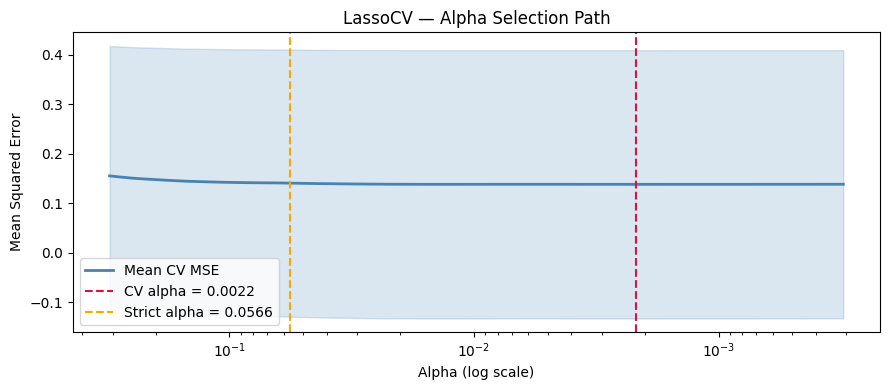

In [14]:
# --- Alpha-path MSE curve ---
# Shows how the cross-validation error changes as alpha increases
mean_mse = np.mean(lasso.mse_path_, axis=1)
std_mse  = np.std(lasso.mse_path_, axis=1)

fig, ax = plt.subplots(figsize=(9, 4))

# Plot the MSE curve with a shaded +/- 1 std band
ax.semilogx(lasso.alphas_, mean_mse, color='steelblue', lw=2, label='Mean CV MSE')
ax.fill_between(lasso.alphas_, mean_mse - std_mse, mean_mse + std_mse,
                alpha=0.2, color='steelblue')

# Mark both alpha values
ax.axvline(lasso.alpha_, color='crimson', ls='--', lw=1.5,
           label=f'CV alpha = {lasso.alpha_:.4f}')
ax.axvline(best_alpha, color='orange', ls='--', lw=1.5,
           label=f'Strict alpha = {best_alpha:.4f}')

ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('LassoCV — Alpha Selection Path')
ax.legend()
ax.invert_xaxis()   # high alpha (strong penalty) on the left
fig.tight_layout()
plt.show()